# Анализ изменения популярности языков программирования на GitHub по годам

В этом ноутбуке пошагово выполняется анализ уже собранных данных.

Ноутбук не делает новые запросы к GitHub API. Сначала нужно запустить `main.py`, чтобы он создал CSV-файлы в папке `data/`, а затем уже открывать и запускать этот ноутбук.

Важно: анализ проводится не по всему GitHub, а по выборке. Для каждой пары `язык + год` в исходной программе используется только первая страница результатов поиска, то есть максимум 100 репозиториев.

## 1. Импорт библиотек

Подключаем библиотеки для обработки таблиц, построения графиков и работы с файлами.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Настройка путей к файлам

Указываем пути к папкам и CSV-файлам, которые были созданы после запуска `main.py`.

In [7]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"

RAW_DATA_PATH = DATA_DIR / "github_repositories.csv"
STATS_DATA_PATH = DATA_DIR / "github_language_stats.csv"

DATA_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

RAW_DATA_PATH, STATS_DATA_PATH

(PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/github_repositories.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/github_language_stats.csv'))

## 3. Загрузка сырых данных

Загружаем файл `github_repositories.csv`, который содержит информацию об отдельных репозиториях.

In [8]:
repositories_df = pd.read_csv(RAW_DATA_PATH)
repositories_df.head()

,repository_name,language,created_at,created_year,stars,forks,open_issues,html_url,description
0,nvbn/thefuck,Python,2015-04-08T15:08:04Z,2015,96790,3933,423,https://github.com/nvbn/thefuck,Magnificent app which corrects your previous c...
1,3b1b/manim,Python,2015-03-22T18:50:58Z,2015,86553,7257,488,https://github.com/3b1b/manim,Animation engine for explanatory math videos
2,keras-team/keras,Python,2015-03-28T00:35:42Z,2015,64053,19761,242,https://github.com/keras-team/keras,Deep Learning for humans
3,charlax/professional-programming,Python,2015-11-07T05:07:52Z,2015,50779,3966,1,https://github.com/charlax/professional-progra...,A collection of learning resources for curious...
4,minimaxir/big-list-of-naughty-strings,Python,2015-08-08T20:57:20Z,2015,47632,2160,108,https://github.com/minimaxir/big-list-of-naugh...,The Big List of Naughty Strings is a list of s...


## 4. Проверка структуры сырых данных

Проверяем размер таблицы, список столбцов и первые строки, чтобы убедиться, что данные загрузились корректно.

In [9]:
print(repositories_df.shape)
print(repositories_df.columns.tolist())
repositories_df.head()

(6600, 9)
['repository_name', 'language', 'created_at', 'created_year', 'stars', 'forks', 'open_issues', 'html_url', 'description']


,repository_name,language,created_at,created_year,stars,forks,open_issues,html_url,description
0,nvbn/thefuck,Python,2015-04-08T15:08:04Z,2015,96790,3933,423,https://github.com/nvbn/thefuck,Magnificent app which corrects your previous c...
1,3b1b/manim,Python,2015-03-22T18:50:58Z,2015,86553,7257,488,https://github.com/3b1b/manim,Animation engine for explanatory math videos
2,keras-team/keras,Python,2015-03-28T00:35:42Z,2015,64053,19761,242,https://github.com/keras-team/keras,Deep Learning for humans
3,charlax/professional-programming,Python,2015-11-07T05:07:52Z,2015,50779,3966,1,https://github.com/charlax/professional-progra...,A collection of learning resources for curious...
4,minimaxir/big-list-of-naughty-strings,Python,2015-08-08T20:57:20Z,2015,47632,2160,108,https://github.com/minimaxir/big-list-of-naugh...,The Big List of Naughty Strings is a list of s...


## 5. Повторное сохранение сырых данных

Этот шаг необязателен, но его можно оставить как подтверждение того, что загруженная таблица может быть снова сохранена в CSV.

In [10]:
repositories_df.to_csv(RAW_DATA_PATH, index=False, encoding="utf-8")
print(f"Saved raw data to: {RAW_DATA_PATH}")

Saved raw data to: /Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/github_repositories.csv


## 6. Загрузка готовой агрегированной таблицы

Файл `github_language_stats.csv` уже создается программой `main.py`. Сначала загружаем его, чтобы увидеть готовые результаты агрегации.

In [11]:
saved_stats_df = pd.read_csv(STATS_DATA_PATH)
print(saved_stats_df.shape)
saved_stats_df.head()

(66, 6)


,language,created_year,repositories_count,total_stars,average_stars,average_forks
0,Go,2015,100,1519891,15198.91,1983.30
1,Go,2016,100,1278320,12783.20,1532.84
2,Go,2017,100,982787,9827.87,1251.46
3,Go,2018,100,1454944,14549.44,1466.92
4,Go,2019,100,1201194,12011.94,1478.46


## 7. Агрегация данных

Для наглядности пересчитываем агрегированные показатели из сырых данных, чтобы показать логику анализа: группировка по языку и году, подсчет числа репозиториев, суммы stars и средних значений.

In [12]:
stats_df = (
    repositories_df.groupby(["language", "created_year"], as_index=False)
    .agg(
        repositories_count=("repository_name", "count"),
        total_stars=("stars", "sum"),
        average_stars=("stars", "mean"),
        average_forks=("forks", "mean"),
    )
    .sort_values(["language", "created_year"])
)

stats_df["average_stars"] = stats_df["average_stars"].round(2)
stats_df["average_forks"] = stats_df["average_forks"].round(2)

stats_df.head(10)

,language,created_year,repositories_count,total_stars,average_stars,average_forks
0,Go,2015,100,1519891,15198.91,1983.30
1,Go,2016,100,1278320,12783.20,1532.84
2,Go,2017,100,982787,9827.87,1251.46
3,Go,2018,100,1454944,14549.44,1466.92
4,Go,2019,100,1201194,12011.94,1478.46
5,Go,2020,100,1044743,10447.43,1154.68
6,Go,2021,100,800274,8002.74,581.02
7,Go,2022,100,656817,6568.17,511.80
8,Go,2023,100,766676,7666.76,662.26
9,Go,2024,100,464061,4640.61,497.86


## 8. Сохранение агрегированных данных

Сохраняем итоговую таблицу со статистиками по языкам и годам.

In [13]:
stats_df.to_csv(STATS_DATA_PATH, index=False, encoding="utf-8")
print(f"Saved aggregated data to: {STATS_DATA_PATH}")
stats_df.shape

Saved aggregated data to: /Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/github_language_stats.csv


(66, 6)

## 9. Визуализация: количество репозиториев по годам

Строим линейный график, который показывает, как менялось количество репозиториев в сохраненной выборке для каждого языка.

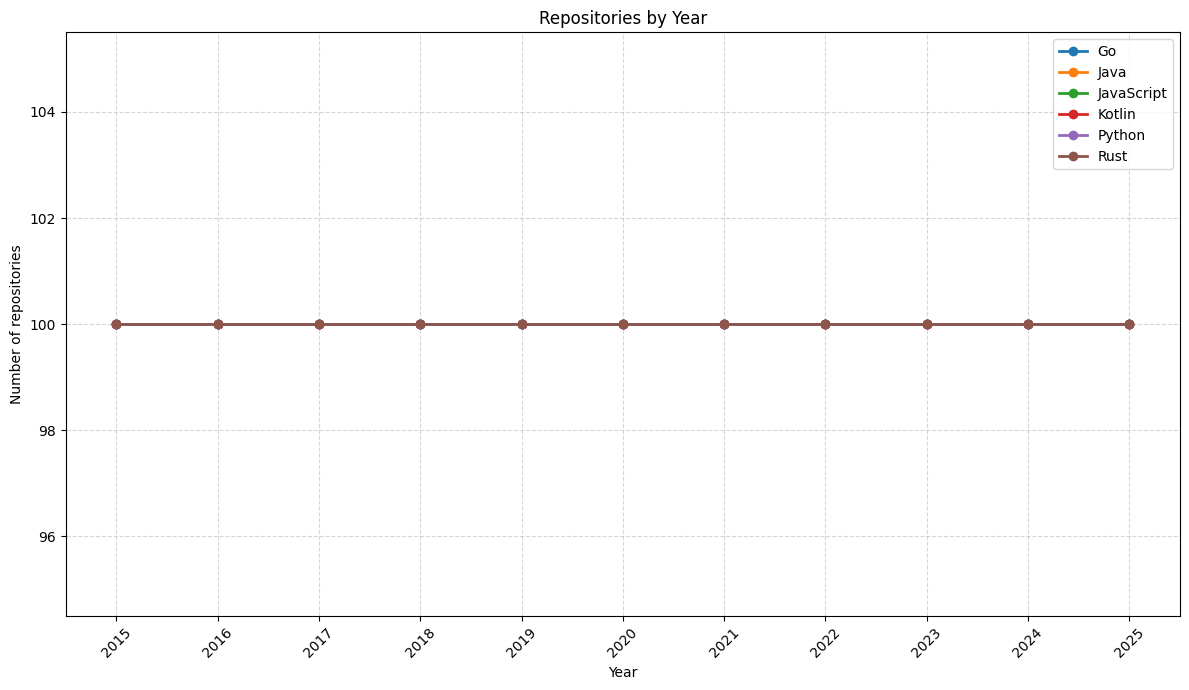

In [14]:
plt.figure(figsize=(12, 7))

for language in stats_df["language"].unique():
    language_data = stats_df[stats_df["language"] == language]
    plt.plot(
        language_data["created_year"],
        language_data["repositories_count"],
        marker="o",
        linewidth=2,
        label=language,
    )

plt.title("Repositories by Year")
plt.xlabel("Year")
plt.ylabel("Number of repositories")
plt.xticks(sorted(stats_df["created_year"].unique()), rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "repositories_by_year.png")
plt.show()

## 10. Визуализация: суммарное количество stars по годам

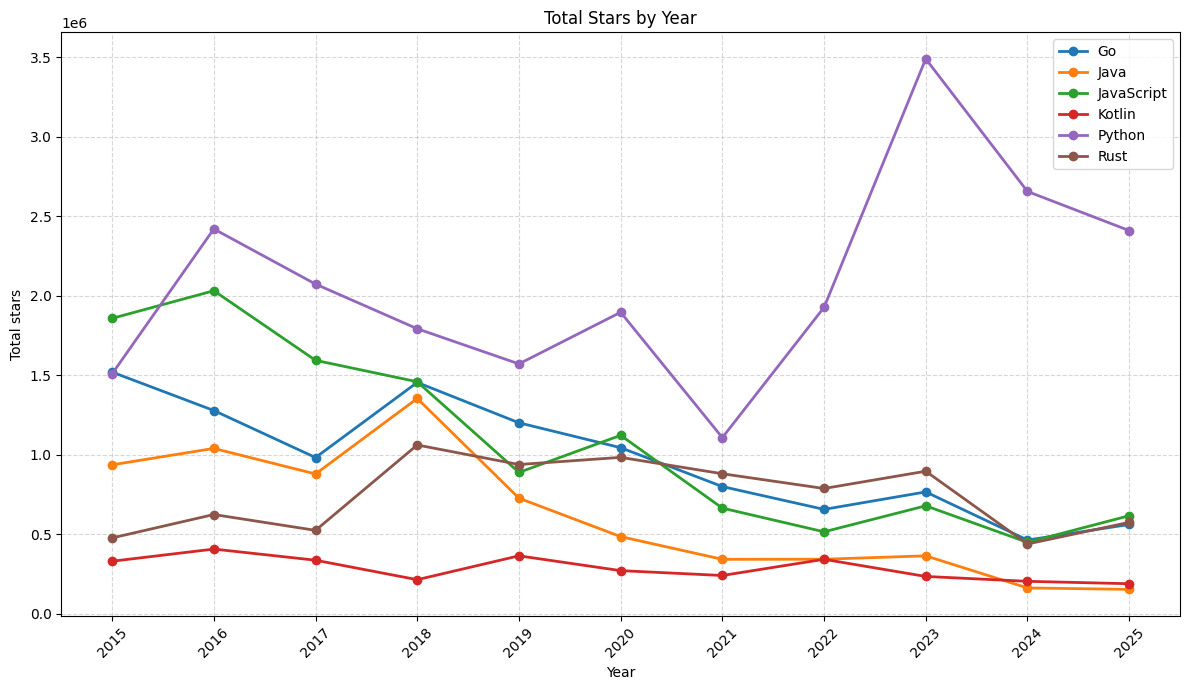

In [15]:
plt.figure(figsize=(12, 7))

for language in stats_df["language"].unique():
    language_data = stats_df[stats_df["language"] == language]
    plt.plot(
        language_data["created_year"],
        language_data["total_stars"],
        marker="o",
        linewidth=2,
        label=language,
    )

plt.title("Total Stars by Year")
plt.xlabel("Year")
plt.ylabel("Total stars")
plt.xticks(sorted(stats_df["created_year"].unique()), rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "stars_by_year.png")
plt.show()

## 11. Визуализация: среднее количество stars по годам

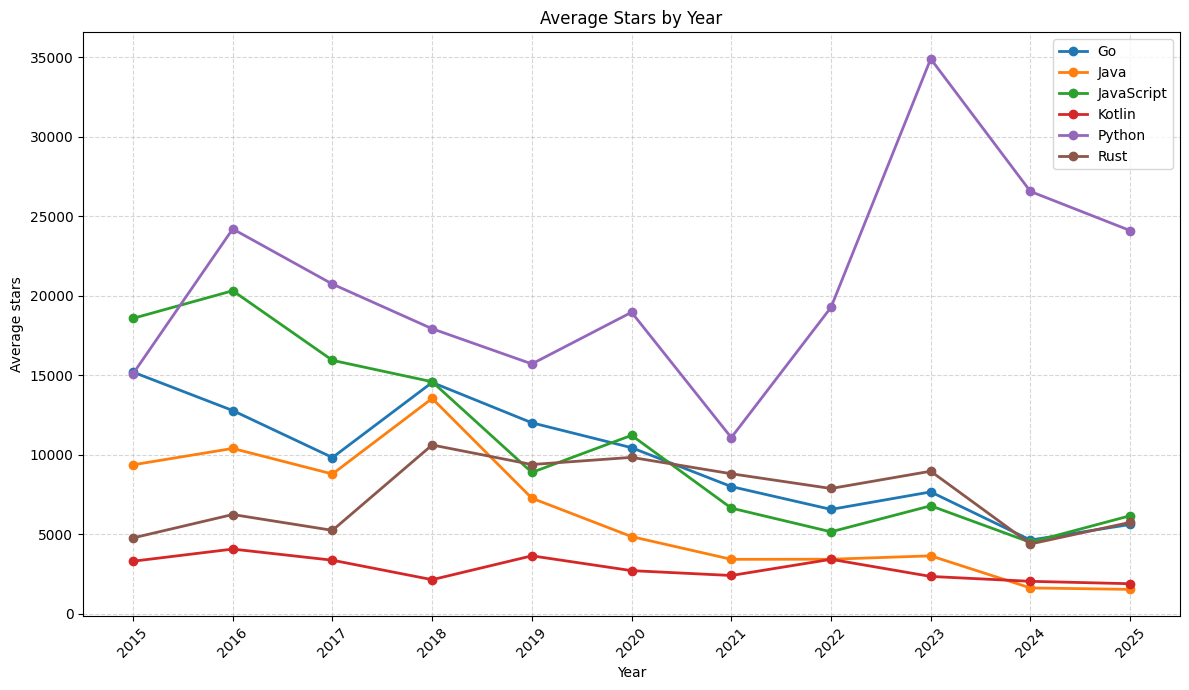

In [16]:
plt.figure(figsize=(12, 7))

for language in stats_df["language"].unique():
    language_data = stats_df[stats_df["language"] == language]
    plt.plot(
        language_data["created_year"],
        language_data["average_stars"],
        marker="o",
        linewidth=2,
        label=language,
    )

plt.title("Average Stars by Year")
plt.xlabel("Year")
plt.ylabel("Average stars")
plt.xticks(sorted(stats_df["created_year"].unique()), rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "average_stars_by_year.png")
plt.show()

## 12. Сравнение языков по общему количеству репозиториев

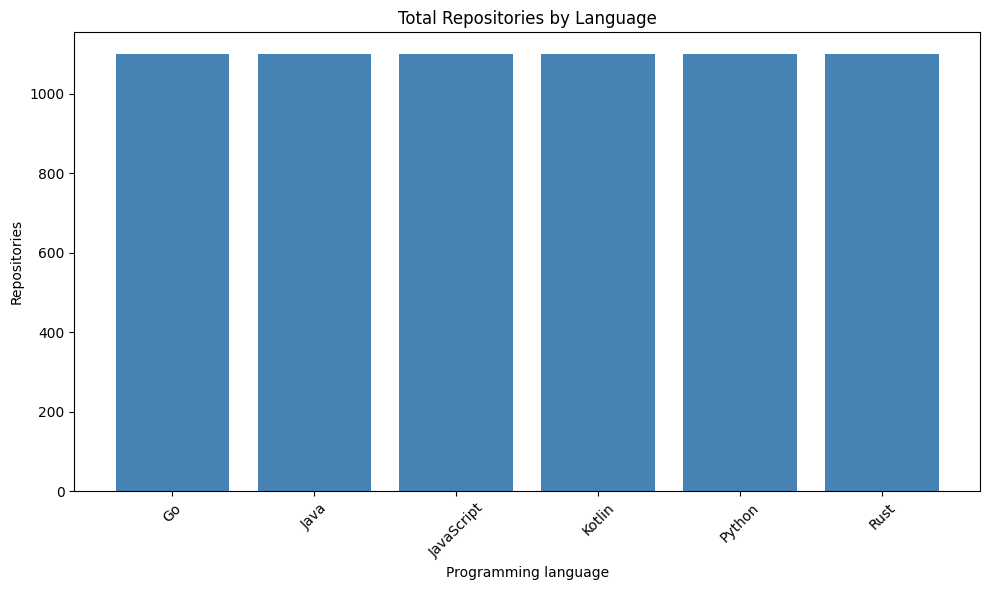

,language,total_repositories,total_stars,mean_average_stars
0,Go,1100,10731547,9755.951818
1,Java,1100,6791965,6174.513636
2,JavaScript,1100,11880331,10800.300909
3,Kotlin,1100,3140593,2855.084545
4,Python,1100,22851747,20774.315455
5,Rust,1100,8191866,7447.150909


In [17]:
totals_df = (
    stats_df.groupby("language", as_index=False)
    .agg(
        total_repositories=("repositories_count", "sum"),
        total_stars=("total_stars", "sum"),
        mean_average_stars=("average_stars", "mean"),
    )
)

totals_df = totals_df.sort_values("total_repositories", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(totals_df["language"], totals_df["total_repositories"], color="steelblue")
plt.title("Total Repositories by Language")
plt.xlabel("Programming language")
plt.ylabel("Repositories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "total_repositories_by_language.png")
plt.show()

totals_df

## 13. Сравнение языков по суммарному количеству stars

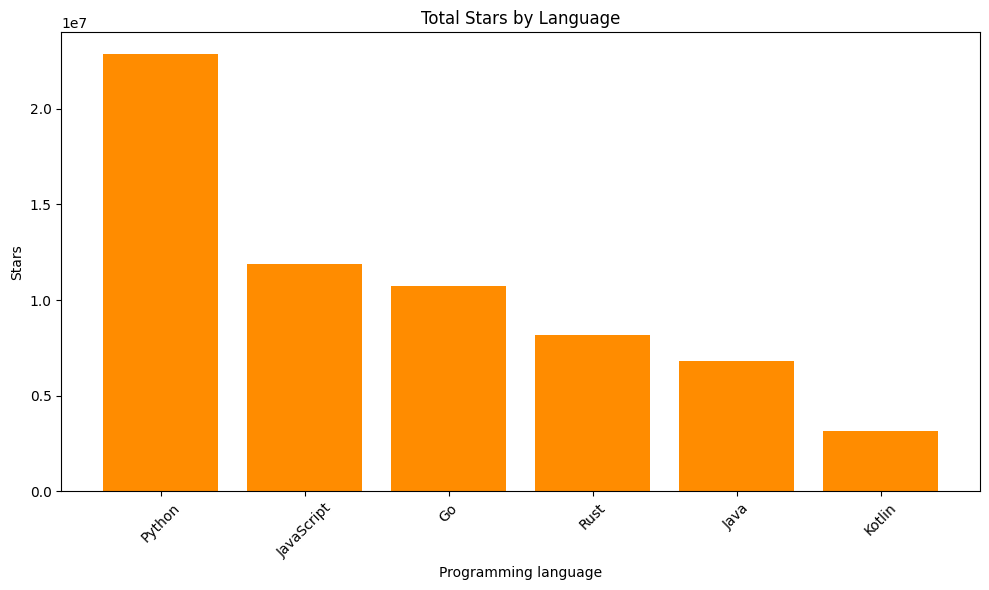

In [18]:
stars_totals_df = totals_df.sort_values("total_stars", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(stars_totals_df["language"], stars_totals_df["total_stars"], color="darkorange")
plt.title("Total Stars by Language")
plt.xlabel("Programming language")
plt.ylabel("Stars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "total_stars_by_language.png")
plt.show()

## 14. Текстовые выводы

На последнем шаге формируем краткие выводы по сохраненной выборке.

In [19]:
most_common_language = totals_df.loc[totals_df["total_repositories"].idxmax(), "language"]
most_starred_language = totals_df.loc[totals_df["total_stars"].idxmax(), "language"]
highest_average_stars_language = totals_df.loc[
    totals_df["mean_average_stars"].idxmax(), "language"
]

growth_languages = []
for language in stats_df["language"].unique():
    language_data = stats_df[stats_df["language"] == language].sort_values("created_year")
    if len(language_data) >= 2:
        if language_data.iloc[-1]["repositories_count"] > language_data.iloc[0]["repositories_count"]:
            growth_languages.append(language)

print("Краткие выводы:")
print(f"- Язык, который чаще всего встречался в выборке: {most_common_language}")
print(f"- Язык с наибольшим суммарным количеством stars: {most_starred_language}")
print(f"- Язык с наибольшим средним количеством stars: {highest_average_stars_language}")
print(f"- Языки, показывающие рост по количеству репозиториев: {', '.join(growth_languages) if growth_languages else 'рост не выявлен'}")
print("- Ограничения: выборка ограничена одной страницей API, учитываются только открытые репозитории, а stars не полностью отражают реальную популярность.")

Краткие выводы:
- Язык, который чаще всего встречался в выборке: Go
- Язык с наибольшим суммарным количеством stars: Python
- Язык с наибольшим средним количеством stars: Python
- Языки, показывающие рост по количеству репозиториев: рост не выявлен
- Ограничения: выборка ограничена одной страницей API, учитываются только открытые репозитории, а stars не полностью отражают реальную популярность.
